# Exploratory Data Analysis (EDA) Report

## Movie Recommendation System – Phase 4 Project

---

# 1. Introduction

This report presents an Exploratory Data Analysis (EDA) of a movie dataset used for building a recommendation system. The goal is to understand data structure, patterns, distributions, and relationships between features such as ratings, genres, popularity, and languages.

---

# 2. Dataset Overview

The dataset contains movie-related information including:

* User ratings
* Movie metadata (title, genres, overview)
* Popularity metrics
* Vote averages
* Release year and language

### Key Columns Used:

* `rating` – User rating
* `vote_average` – Average movie rating
* `genres_x` – Movie genres
* `original_language` – Language of movie
* `popularity` – Popularity score
* `year` – Release year




In [64]:
#load libraries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# loading data set

In [65]:
final_dataset = pd.read_csv('final_dataset.csv')


In [66]:
final_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321026 entries, 0 to 321025
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   userid             321026 non-null  int64  
 1   movieid            321026 non-null  int64  
 2   rating             321026 non-null  float64
 3   timestamp          321026 non-null  object 
 4   clean_title        321026 non-null  object 
 5   id                 321026 non-null  int64  
 6   vote_average       321026 non-null  float64
 7   vote_count         321026 non-null  int64  
 8   release_date       262143 non-null  object 
 9   revenue            321026 non-null  int64  
 10  runtime            321026 non-null  int64  
 11  adult              321026 non-null  bool   
 12  budget             321026 non-null  int64  
 13  imdb_id            197481 non-null  object 
 14  original_language  321026 non-null  object 
 15  original_title     321026 non-null  object 
 16  ov

## Convert to Movie-Level Dataset

In [67]:
# Aggregate to movie level
movie_df = final_dataset.groupby('movieid').agg({
    'clean_title': 'first',
    'genres': 'first',
    'vote_average': 'first',
    'vote_count': 'first',
    'popularity': 'first',
    'runtime': 'first',
    'budget': 'first',
    'revenue': 'first',
    'release_year': 'first',
    'language_name': 'first',
    'rating': ['mean', 'count']
}).reset_index()

# Rename columns
movie_df.columns = [
    'movieid','title','genres','vote_average','vote_count',
    'popularity','runtime','budget','revenue','release_year',
    'language_name','avg_user_rating','num_ratings'
]

In [68]:
# Basic Information ======================
print("Dataset Shape:", movie_df.shape)
print("\nNumerical Columns Summary:")
print(movie_df.describe())

Dataset Shape: (6834, 13)

Numerical Columns Summary:
             movieid  vote_average    vote_count   popularity      runtime  \
count    6834.000000   6834.000000   6834.000000  6834.000000  6834.000000   
mean    46730.498976      6.418172   1630.263096    16.845717   103.328505   
std     55995.454386      0.954403   3088.554133    14.820479    24.394243   
min         1.000000      0.000000      0.000000     0.000000     0.000000   
25%      3323.250000      5.925250    133.000000     8.688750    92.000000   
50%      7599.000000      6.490000    453.000000    13.411500   101.000000   
75%     88128.000000      7.028750   1604.000000    20.073750   114.000000   
max    193609.000000      8.573000  34495.000000   225.659000   467.000000   

             budget       revenue  release_year  avg_user_rating  num_ratings  
count  6.834000e+03  6.834000e+03   6834.000000      6834.000000  6834.000000  
mean   2.125677e+07  6.410400e+07   1992.866989         3.198164    46.974832  
std

## type conversion 
 numerical & date coonversion
 converts these columns from strings to floating-point numbers
 converts a string into a Datetime object 

In [69]:
movie_df['vote_average'] = pd.to_numeric(movie_df['vote_average'], errors='coerce')
movie_df['popularity'] = pd.to_numeric(movie_df['popularity'], errors='coerce')
final_dataset['release_date'] = pd.to_datetime(final_dataset['release_date'], errors='coerce')
print("vote_average column data type:", movie_df['vote_average'].dtype)
print("popularity column data type:", movie_df['popularity'].dtype)
print("release_date column data type:", final_dataset['release_date'].dtype)

vote_average column data type: float64
popularity column data type: float64
release_date column data type: datetime64[ns]


# DATA ANALISIS

## avarage rating by genre
Insight:
* action and adventure tend to have higher average ratings
* Some popular genres have moderate ratings due to volume

In [70]:
final_genre = movie_df[['genres', 'vote_average']].copy()
final_genre['genres'] = final_genre['genres'].str.split(',')
final_genre = final_genre.explode('genres')

avg_rating = final_genre.groupby('genres')['vote_average'].mean()
avg_rating

genres
 Action                                 6.342229
 Adventure                              6.312327
 Animation                              6.792864
 Comedy                                 6.317912
 Crime                                  6.416616
 Documentary                            7.017455
 Drama                                  6.553053
 Family                                 6.383101
 Fantasy                                6.367386
 History                                6.877824
 Horror                                 5.972310
 Music                                  6.626169
 Mystery                                6.554370
 Romance                                6.452857
 Science Fiction                        6.212702
 TV Movie                               6.663819
 Thriller                               6.336948
 War                                    6.802628
 Western                                6.502507
Action                                  6.187001
Action|Advent

## Technical Breakdown
*  ROI (Return on Investment) - This calculates how much is made for a production to releasing.
* Decade-Grouping by decade allows you to see long-term trends
* Popularity Bins -It turns a messy decimal number into a simple category .

In [71]:
# ROI
movie_df['ROI'] = (movie_df['revenue'] - movie_df['budget']) / movie_df['budget']
movie_df['ROI'] = movie_df['ROI'].replace([float('inf'), -float('inf')], 0)

# Decade
movie_df['Decade'] = (movie_df['release_year'] // 10) * 10

# Popularity bins
movie_df['popularity_bin'] = pd.cut(movie_df['popularity'], bins=5)

print(movie_df['ROI'].describe())
print(movie_df['Decade'].value_counts())
print(movie_df['popularity_bin'].value_counts())

count    5.040000e+03
mean     3.634137e+02
std      2.205583e+04
min     -1.000000e+00
25%     -1.446376e-01
50%      5.444548e-01
75%      2.624729e+00
max      1.545929e+06
Name: ROI, dtype: float64
Decade
2000    1946
2010    1698
1990    1463
1980     793
1970     282
1960     205
1950     165
1940     115
1930      85
2020      48
1920      16
0         14
1900       3
1910       1
Name: count, dtype: int64
popularity_bin
(-0.226, 45.132]      6552
(45.132, 90.264]       242
(90.264, 135.395]       30
(135.395, 180.527]       8
(180.527, 225.659]       2
Name: count, dtype: int64


## calcutating gross

In [88]:
# Calculate gross profit
movie_df['gross'] = movie_df['revenue'] - movie_df['budget']
print(movie_df['gross'].describe())

count    6.834000e+03
mean     4.284722e+07
std      1.259919e+08
min     -1.110072e+08
25%      0.000000e+00
50%      4.937135e+05
75%      3.261021e+07
max      2.686706e+09
Name: gross, dtype: float64


# visualization 

## Budget vs Gross
I conduct a bivariate analysis comparing production budgets to gross revenue

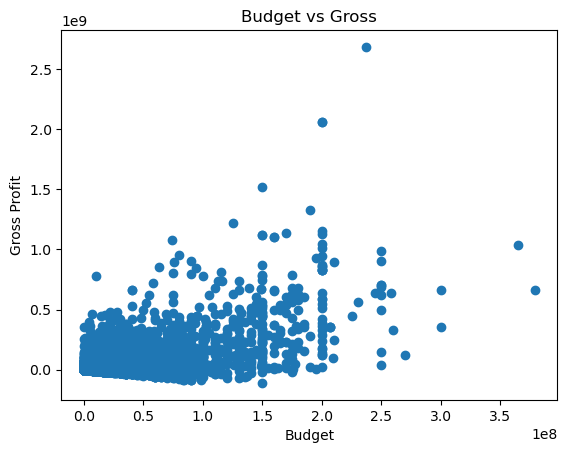

In [89]:

plt.figure()
plt.scatter(movie_df['budget'], movie_df['gross'])
plt.xlabel("Budget")
plt.ylabel("Gross Profit")
plt.title("Budget vs Gross")
plt.show()

## Identifying High-Performing Genres by Average Rating
This visualization investigates which genres consistently receive the highest praise from users. Unlike a simple frequency count, this analysis focuses on perceived quality, helping us understand user sentiment across different content categories

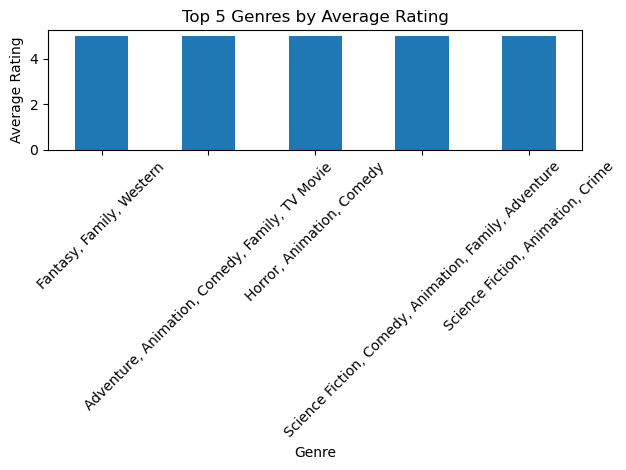

In [72]:


# Split genres
df_genre = movie_df.copy()
df_genre['genres'] = df_genre['genres'].fillna('')

df_genre = df_genre.assign(genres=df_genre['genres'].str.split('|')).explode('genres')

# Remove empty genres
df_genre = df_genre[df_genre['genres'] != ""]

# Compute average rating
genre_rating = df_genre.groupby('genres')['avg_user_rating'].mean().sort_values(ascending=False)

# Select TOP 5
top5_genres = genre_rating.head(5)

# Plot
plt.figure()
top5_genres.plot(kind='bar')
plt.title("Top 5 Genres by Average Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Relationship Between Movie Runtime and Audience Engagement
In this section, we analyzed how a movie's duration influences the volume of user ratings.
* The 90-120 Minute Peak: The distribution shows a massive concentration of engagement for movies between 90 and 120 minutes. This confirms that standard feature-length films drive the highest volume of user interaction

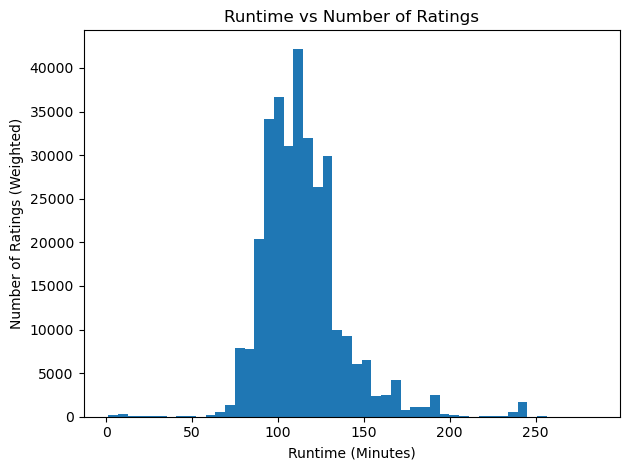

In [73]:
from pandas._libs.tslibs.offsets import Minute
# Count ratings per movie
movie_counts = movie_df.set_index('movieid')['num_ratings']

# Merge with runtime
runtime_df = movie_df[['movieid','runtime']].drop_duplicates()

runtime_df = runtime_df.merge(movie_counts, on='movieid')
runtime_df.columns = ['movieid','runtime','num_ratings']

# Remove invalid values
runtime_df = runtime_df[(runtime_df['runtime'] > 0) & (runtime_df['runtime'] < 300)]

# Plot
plt.figure()
plt.hist(runtime_df['runtime'], bins=50, weights=runtime_df['num_ratings'])
plt.title("Runtime vs Number of Ratings")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Ratings (Weighted)")
plt.tight_layout()
plt.show()

## Popularity vs Rating 
### Weak Relationship
* The correlation value you printed is likely close to 0 .
* This indicates a weak positive relationship between popularity and rating.
   As popularity increases, ratings do not consistently increase

In [74]:
correlation = movie_df['popularity'].corr(movie_df['vote_average'])
correlation

np.float64(0.24351758555275077)

Text(0, 0.5, 'Vote Average')

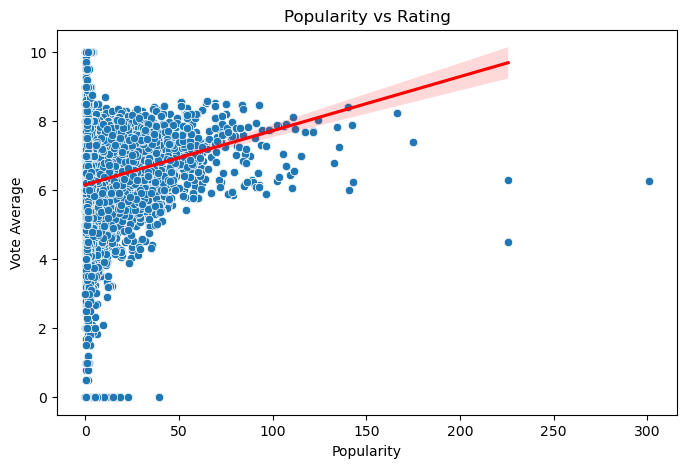

In [75]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x='popularity',y='vote_average',data=final_dataset)

# Optional: add trend line
sns.regplot(x='popularity',y='vote_average',data=movie_df,scatter=False,color='red')

plt.title("Popularity vs Rating")
plt.xlabel("Popularity")
plt.ylabel("Vote Average")

# Movie ratings distribution


* Most movies fall in mid-to-high rating range
* Few extremely low-rated movies exist


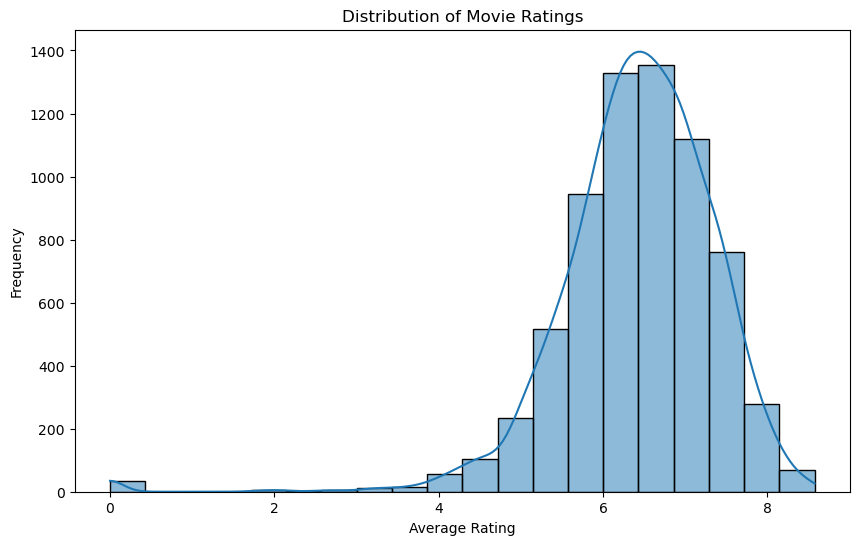

In [76]:
# movie rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(movie_df['vote_average'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")          
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

# genre distribution
This code creates a frequency visualization of the most common genres in the dataset. 

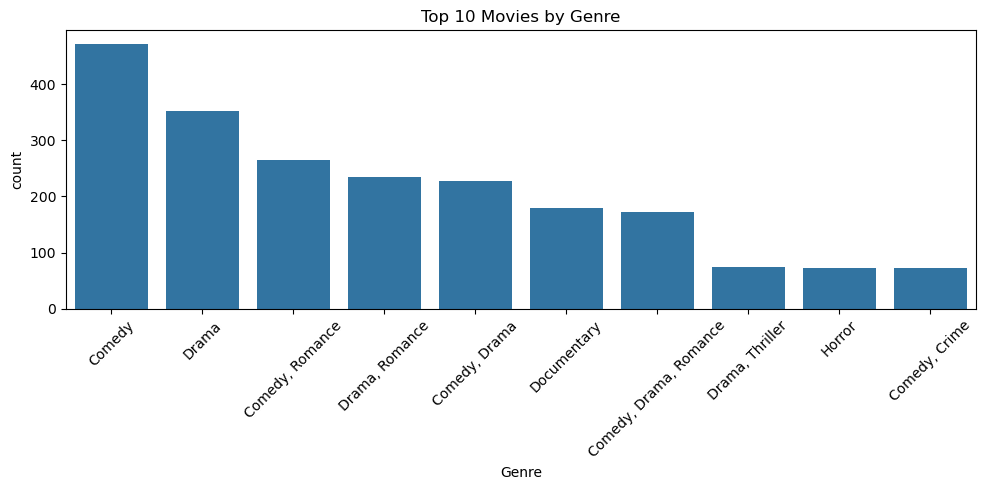

In [77]:

# Top 10 Genres
top_genres = movie_df['genres'].value_counts().nlargest(10).index
plt.figure(figsize=(10, 5))
sns.countplot(x='genres', data=movie_df[movie_df['genres'].isin(top_genres)], order=top_genres)
plt.title("Top 10 Movies by Genre")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Genre vs Rating

* Helps identify quality vs quantity trends


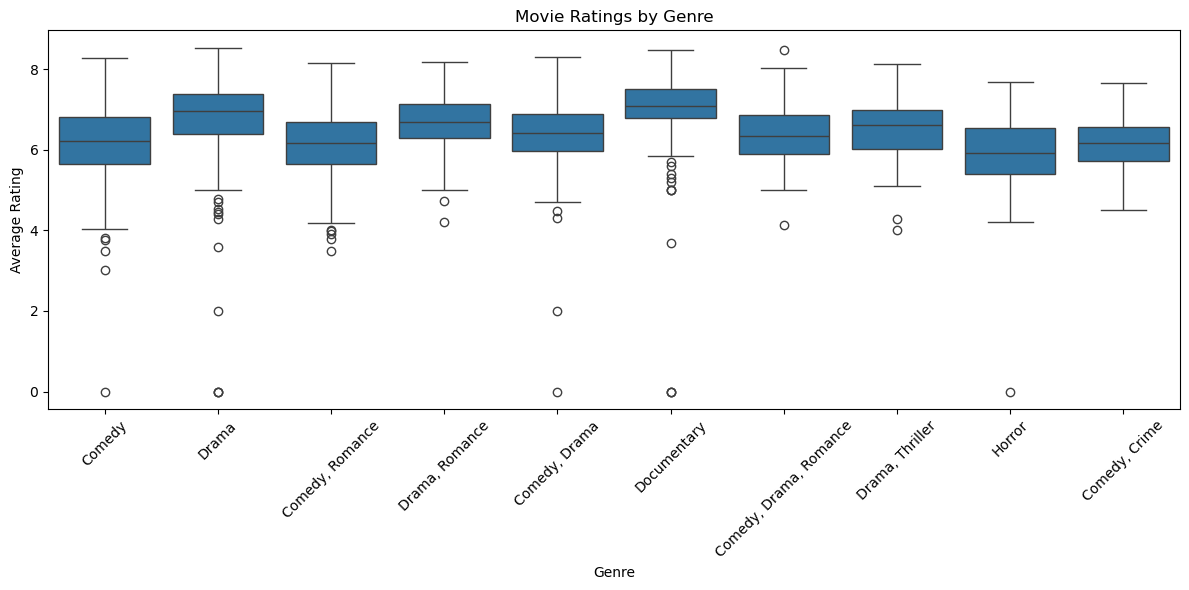

In [78]:
# genre vs rating
plt.figure(figsize=(12, 6))
sns.boxplot(x='genres', y='vote_average', data=movie_df[movie_df['genres'].isin(top_genres)], order=top_genres)
plt.title("Movie Ratings by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue & budget
This code creates a Scatter Plot to visualize the relationship between how much a movie cost to make (Budget) and how much it earned (Revenue)

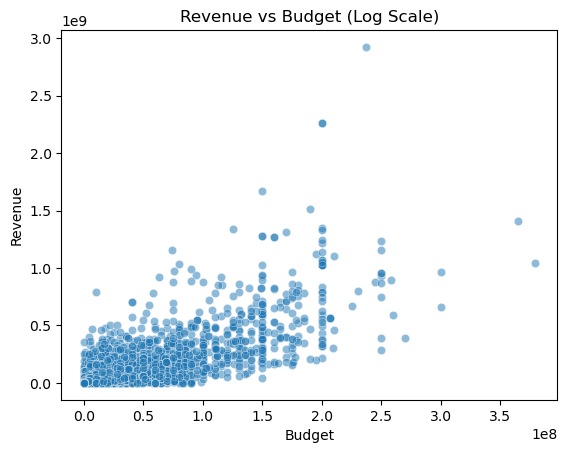

In [79]:
sns.scatterplot(x='budget', y='revenue', data=movie_df, alpha=0.5)
plt.title("Revenue vs Budget (Log Scale)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

# Distribution of Languages
* English is dominant language


this code creates a frequency distribution bar chart for the most common languages in the dataset.


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'English'),
  Text(1, 0, 'French'),
  Text(2, 0, 'Chinese'),
  Text(3, 0, 'Russian'),
  Text(4, 0, 'Spanish'),
  Text(5, 0, 'Japanese'),
  Text(6, 0, 'German'),
  Text(7, 0, 'Portuguese')])

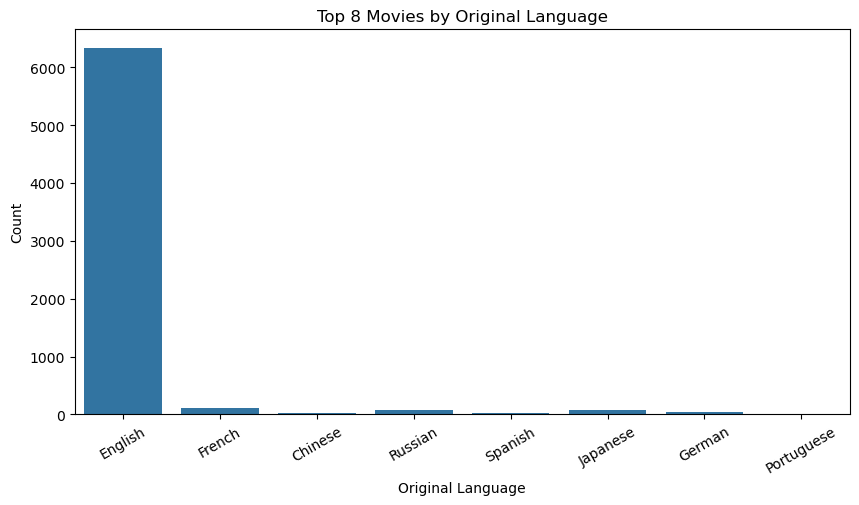

In [80]:
# Get top 8 languages
language_map = {
    'en': 'English',
    'fr': 'French',
    'es': 'Spanish',
    'de': 'German',
    'it': 'Italian',
    'ja': 'Japanese',
    'ko': 'Korean',
    'zh': 'Chinese',
    'hi': 'Hindi',
    'ru': 'Russian',
    'pt': 'Portuguese',
    'ar': 'Arabic'
}
top_langs_codes = final_dataset['original_language'].value_counts().head(8).index
top_langs = [language_map.get(code, code) for code in top_langs_codes]

plt.figure(figsize=(10, 5))  # adjust size for better fit

sns.countplot(x='language_name', data=movie_df[movie_df['language_name'].isin(top_langs)], order=top_langs)

plt.title("Top 8 Movies by Original Language")
plt.xlabel("Original Language")
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=30)

## numerical feature
This code block creates a 2x2 grid of histograms to analyze the distributions of your most important numerical variables

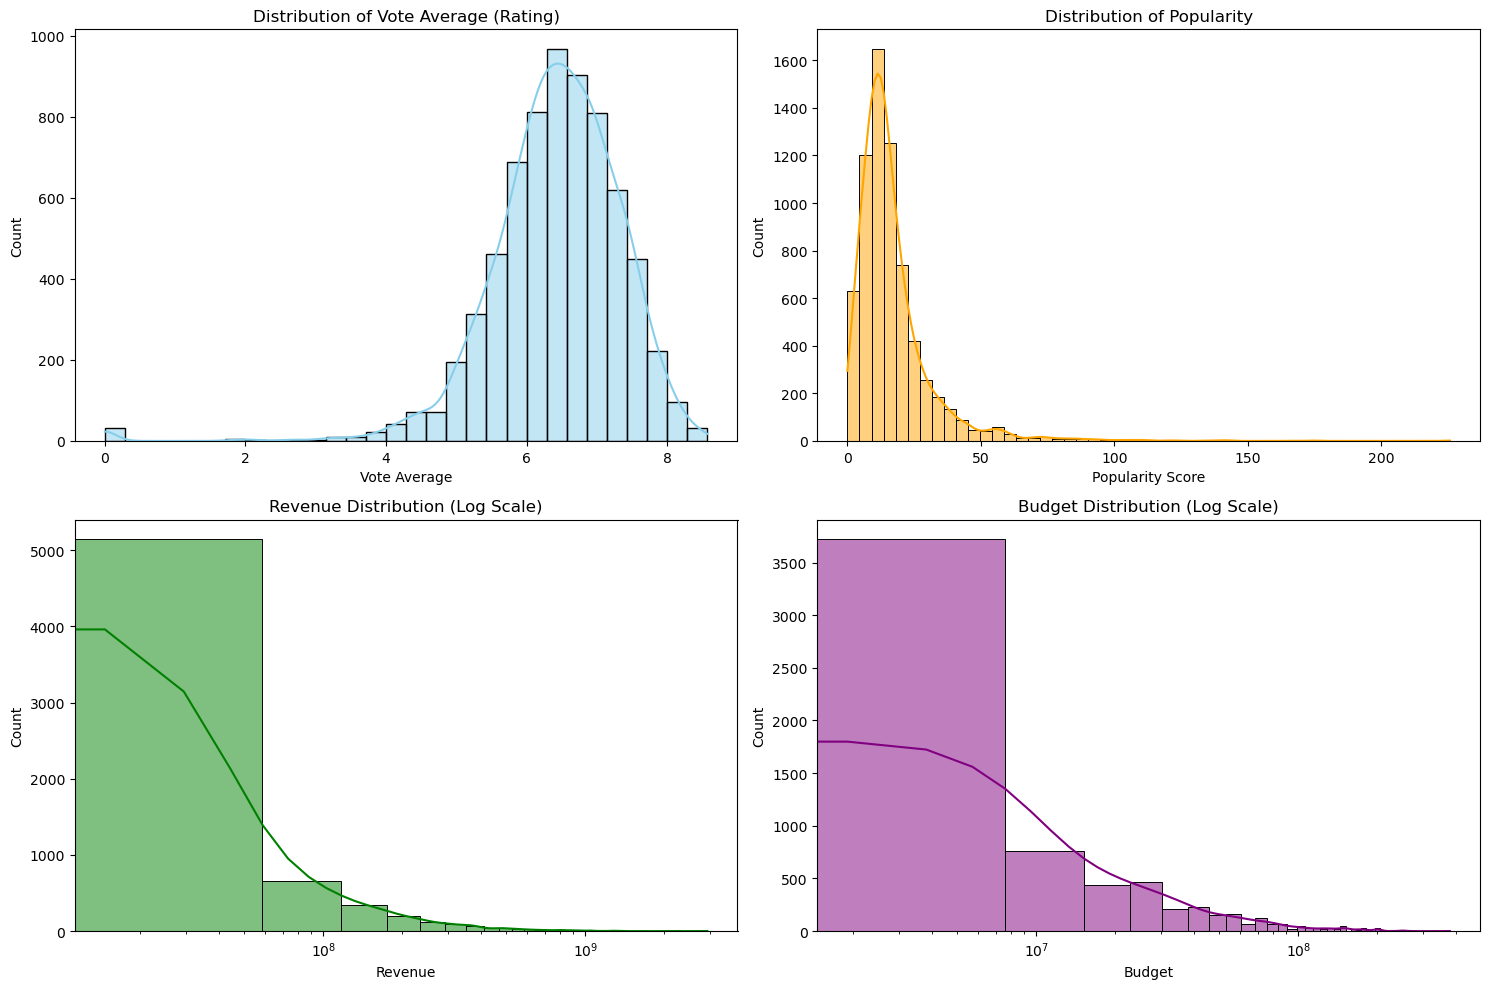

In [81]:
#  Distribution of Key Numerical Features ======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Vote Average Distribution
sns.histplot(movie_df['vote_average'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Vote Average (Rating)')
axes[0,0].set_xlabel('Vote Average')

# Popularity Distribution
sns.histplot(movie_df['popularity'], bins=50, kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Distribution of Popularity')
axes[0,1].set_xlabel('Popularity Score')

# Revenue Distribution (log scale because it's highly skewed)
sns.histplot(movie_df['revenue'], bins=50, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Revenue Distribution (Log Scale)')
axes[1,0].set_xscale('log')
axes[1,0].set_xlabel('Revenue')

# Budget Distribution
sns.histplot(movie_df['budget'], bins=50, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Budget Distribution (Log Scale)')
axes[1,1].set_xscale('log')
axes[1,1].set_xlabel('Budget')

plt.tight_layout()
plt.show()






# Movies Over Time
Insight:
* Movie production increases significantly in recent years
* Indicates dataset bias toward modern films

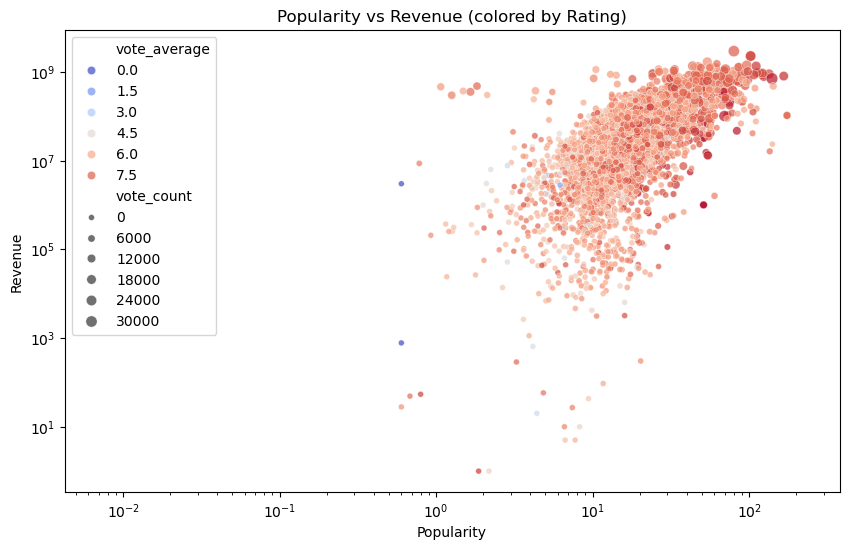

In [82]:
#  Scatter Plot: Popularity vs Revenue ======================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_df, x='popularity', y='revenue', hue='vote_average',
                size='vote_count', alpha=0.7, palette='coolwarm')
plt.title('Popularity vs Revenue (colored by Rating)')
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.xscale('log')
plt.yscale('log')
plt.show()



# Boxplot (Popularity Binned vs Rating)
Shows how ratings vary across popularity groups

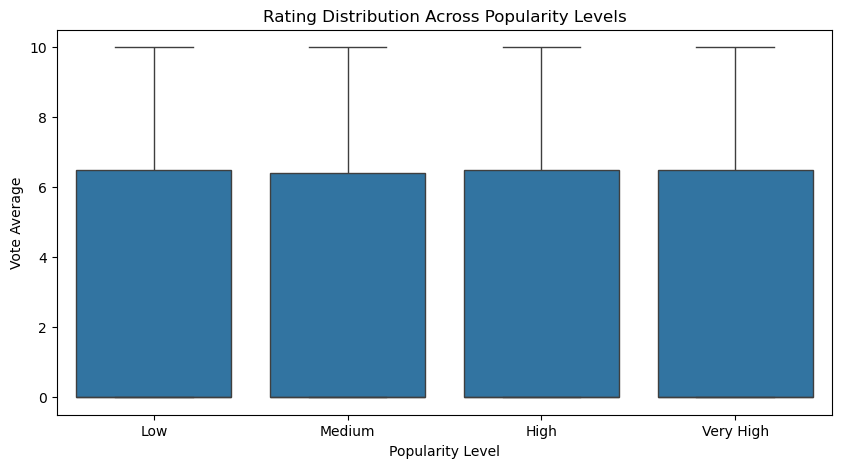

In [83]:
# Create bins for popularity
final_dataset['popularity_bin'] = pd.qcut(movie_df['popularity'], 4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='popularity_bin',
    y='vote_average',
    data=final_dataset
)

plt.title("Rating Distribution Across Popularity Levels")
plt.xlabel("Popularity Level")
plt.ylabel("Vote Average")

plt.show()

## Correlation heatmap
*  It measures the strength of the linear relationship between your numerical variables, ranging from -1 to +1.

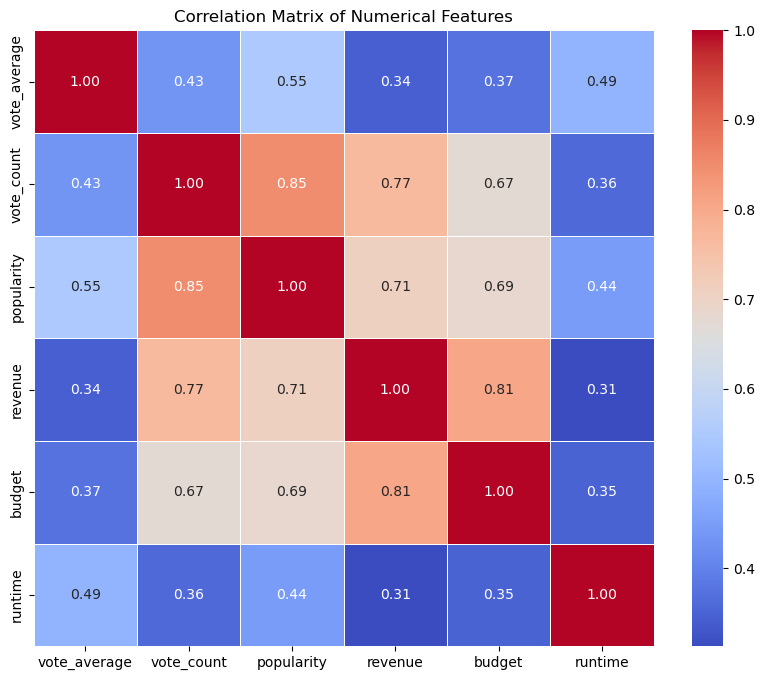

In [84]:
#  Correlation Heatmap ======================
numerical_cols = ['vote_average', 'vote_count', 'popularity', 'revenue', 'budget', 'runtime']

plt.figure(figsize=(10, 8))
corr_matrix = final_dataset[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Create Smaller Dataset for Tableau

In [85]:
movie_df.to_csv("tableau_movies_small.csv", index=False)

 # 7. Key Findings

### 7.1 Content Trends

* Drama and Action dominate movie production

### 7.2 Rating Insights

* High-rated movies are not always popular

### 7.3 Language Insights

* English movies dominate dataset

### 7.4 Dataset Bias

* More recent movies are overrepresented

---

# 8. Feature Engineering for Recommendation System

The dataset was prepared for recommendation modeling using:

* `combined_features` (text-based representation)
* Genre encoding
* Language encoding

This enables:

* Content-based filtering
* TF-IDF vectorization
* Cosine similarity modeling

---

# 9. Conclusion

This EDA provides a strong understanding of the dataset and prepares it for building a movie recommendation system. Key patterns in genres, ratings, and languages were identified, which will guide model development in later phases.

---

# 10. Next Steps

* Build TF-IDF vectorizer
* Compute cosine similarity
* Create recommendation function
* Evaluate recommendation quality

---

✔ End of EDA Report
